Using device: cpu
Epoch 1/5 | Loss: 322.1078
Epoch 2/5 | Loss: 130.2713
Epoch 3/5 | Loss: 88.1622
Epoch 4/5 | Loss: 67.6495
Epoch 5/5 | Loss: 52.9101
Total Accuracy: 97.42%
Model Saved as mnist_model.pth


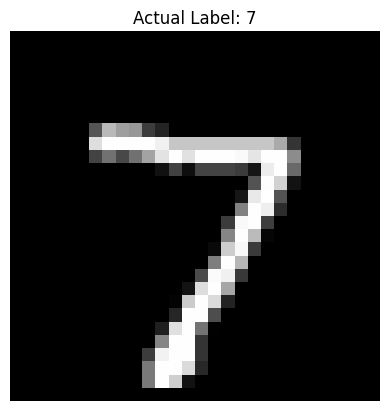

User picked image index: 0
Actual label: 7
Model Prediction: 7


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Transform
transform = transforms.ToTensor()

# Dataset
train_data = MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_data = MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

# DataLoader
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# Model
class DigitModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)

model = DigitModel().to(device)

# Loss & Optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training
epochs = 5
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f}")

# Evaluation
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"Total Accuracy: {accuracy:.2f}%")

# Save model
torch.save(model.state_dict(), "mnist_model.pth")
print("Model Saved as mnist_model.pth")

# Prediction on single image
index = 0
image, true_label = test_data[index]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Actual Label: {true_label}")
plt.axis("off")
plt.show()

image_flat = image.view(1, -1).to(device)
with torch.no_grad():
    output = model(image_flat)
    predicted_label = output.argmax(dim=1).item()

print("User picked image index:", index)
print("Actual label:", true_label)
print("Model Prediction:", predicted_label)